# First plotting attempt of example data

In [1]:
#import packages
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import os
import inspect
import pandas as pd

import geopandas as gpd
from shapely.geometry import Point

#### define input and outputs

In [2]:
#inputs
#input data
input_file_path = '../01_data/01_input_data/02_processed/'

#original network
original_network_file = 'input_network_data.xlsx'

#outputs

#get path
current_folder_path = os.getcwd()
parent_folder_path = os.path.abspath(os.path.join(current_folder_path, os.pardir))

# Specify the subfolder name
output_folder = '/02_plots/'

#create path to correct folder
images_folder_path = parent_folder_path + output_folder

#replace \ by correct one:/
images_folder_path = images_folder_path.replace("\\", "/")

#### read in the data

In [3]:
original_network_df = pd.read_excel(input_file_path + original_network_file)
original_network_df

,source,target,capacity,source_name,target_name
0,"(757926.5454303586, 7207322.22114858)","(807807.6960599166, 7159118.912010687)",27.809143,node_0001,node_0002
1,"(757926.5454303586, 7207322.22114858)","(807807.6960599166, 7159118.912010687)",27.809143,node_0001,node_0002
2,"(807807.6960599166, 7159118.912010687)","(815843.850100283, 7134574.8782972265)",65.753400,node_0002,node_0362
3,"(681661.3396489053, 6764564.505472038)","(637008.0862654719, 6772214.151799204)",27.809143,node_0003,node_0004
4,"(681661.3396489053, 6764564.505472038)","(682552.0068947424, 6728692.507370236)",6.329657,node_0003,node_0196
...,...,...,...,...,...
1015,"(1578045.0639771034, 7151621.849673391)","(1596573.6366221898, 7137478.869636691)",2.000000,node_0377,node_0656
1016,"(1067619.5952070616, 6021525.093097464)","(1068770.638741864, 6030297.861735745)",2.234585,node_0378,node_0611
1017,"(781423.8635470029, 6822588.252173902)","(710902.966129464, 6885968.896764138)",27.650787,node_0379,node_0657
1018,"(830186.2532940885, 7111961.970883027)","(274855.1698549848, 8006943.521699804)",27.809143,node_0380,node_0658


In [10]:
# Extract unique nodes and their coordinates
# Create separate dataframes for source nodes and target nodes
source_nodes = original_network_df[['source_name', 'source']].drop_duplicates().reset_index(drop=True)
target_nodes = original_network_df[['target_name', 'target']].drop_duplicates().reset_index(drop=True)

# Rename columns for clarity
source_nodes.columns = ['node_name', 'coordinates']
target_nodes.columns = ['node_name', 'coordinates']

# Concatenate the two dataframes for the nodes and coordinates dataframe
unique_nodes = pd.concat([source_nodes, target_nodes]).drop_duplicates().reset_index(drop=True)

#create an edges dataframe
edges_original_network_df = original_network_df[['source_name', 'target_name']]
# Assuming 'df' is your existing data frame

# New column data that all pipes exist
new_column_data = 'existing'

# Specify the index where you want to insert the new column (2 in this example)
index_to_insert = 2

# Use the insert method to add a new column named 'type' at the specified index
edges_original_network_df.insert(index_to_insert, 'type', new_column_data)

In [5]:
# Create a directed graph
G = nx.DiGraph()

# Add nodes with coordinates (to have a better illustration)
nodes = {
    'S1': (0, 1),
    'S2': (0, 0),
    'S3': (0, -1),
    'D1': (1, 1),
    'D2': (1, 0),
    'D3': (1, -1),
    'D4': (2, 0),
    'D5': (3, 1),
    'D6': (3, -1),
    'D7': (4, -1),
    'D8': (4, 1),
    'D9': (5, 1),
    'D10': (5, -1),
}

G.add_nodes_from(nodes)

# Add edges from the table with edge types from methane
edges_methane = [
    ('S1', 'D1', {'type': 'existing'}),
    ('S1', 'D2', {'type': 'existing'}),
    ('S2', 'D2', {'type': 'existing'}),
    ('S2', 'D3', {'type': 'new'}),
    ('S3', 'D1', {'type': 'existing'}),
    ('D1', 'D2', {'type': 'existing'}),
    ('D3', 'D4', {'type': 'new'}),
    ('D4', 'D5', {'type': 'new'}),
    ('D4', 'D6', {'type': 'existing'}),
    ('D6', 'D7', {'type': 'existing'}),
    ('D5', 'D8', {'type': 'existing'}),
    ('D5', 'D9', {'type': 'existing'}),
    ('D9', 'D10', {'type': 'existing'}),
    ('D7', 'D10', {'type': 'existing'}),
]

#hydrogen grid edges
edges_hy = [
    ('S1', 'D2', {'type': 'new'}),
    ('S2', 'D3', {'type': 'converted'}),
    ('S3', 'D1', {'type': 'new'}),
    ('D3', 'D4', {'type': 'converted'}),
    ('D4', 'D5', {'type': 'converted'}),
    ('D4', 'D6', {'type': 'new'}),
    ('D6', 'D7', {'type': 'new'}),
    ('D5', 'D8', {'type': 'new'}),
    ('D5', 'D9', {'type': 'new'}),
    ('D9', 'D10', {'type': 'new'}),
]

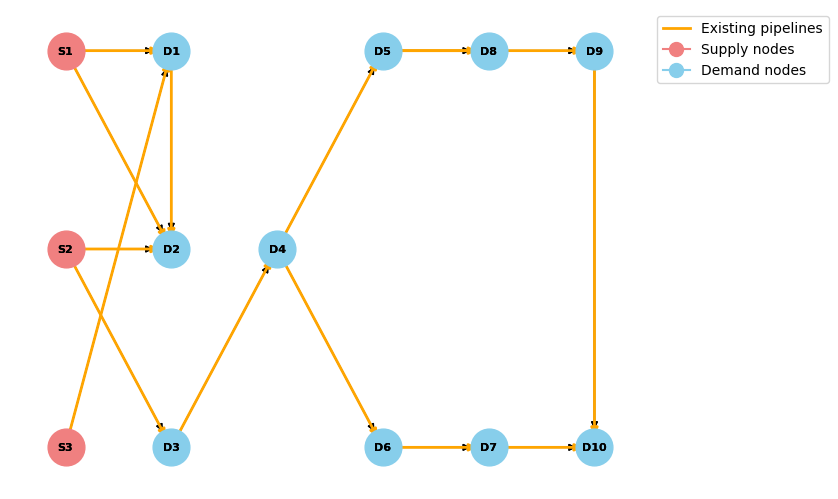

In [14]:
#plot original methane grid

# Add edges from the table with edge types from methane
edges_origin = [
    ('S1', 'D1', {'type': 'existing'}),
    ('S1', 'D2', {'type': 'existing'}),
    ('S2', 'D2', {'type': 'existing'}),
    ('S2', 'D3', {'type': 'existing'}),
    ('S3', 'D1', {'type': 'existing'}),
    ('D1', 'D2', {'type': 'existing'}),
    ('D3', 'D4', {'type': 'existing'}),
    ('D4', 'D5', {'type': 'existing'}),
    ('D4', 'D6', {'type': 'existing'}),
    ('D6', 'D7', {'type': 'existing'}),
    ('D5', 'D8', {'type': 'existing'}),
    ('D5', 'D9', {'type': 'existing'}),
    ('D9', 'D10', {'type': 'existing'}),
    ('D7', 'D10', {'type': 'existing'}),
]

# Separate nodes with 'S' in their names and others
s_nodes = [node for node in G.nodes if 'S' in node]
other_nodes = [node for node in G.nodes if 'S' not in node]

#plot methane grid
G.add_edges_from(edges_origin)

# Separate edges by type
new_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'new']
existing_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'existing']

# Plot the graph with node coordinates and different colors for edge types
pos = nodes
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=s_nodes, node_color='lightcoral', label='Supply nodes')
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=other_nodes, node_color='skyblue', label='Demand nodes')
nx.draw_networkx_edges(G, pos, edgelist=new_edges, edge_color='green', label='New edges', width=2)
nx.draw_networkx_edges(G, pos, edgelist=existing_edges, edge_color='orange', label='Existing edges', width=2)

# Create separate Line2D objects for each edge type for the legend
legend_elements = [
    Line2D([0], [0], color='orange', lw=2, label='Existing pipelines'),
    Line2D([0], [0], marker='o', color='lightcoral', markerfacecolor='lightcoral', markersize=10, label='Supply nodes'),
    Line2D([0], [0], marker='o', color='skyblue', markerfacecolor='skyblue', markersize=10, label='Demand nodes'),
]

# Display the legend with adjusted position and include node and edge elements
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

#output_filepath = os.path.join(output_folder, 'network_methane_plot.png')
plt.savefig(images_folder_path + 'network_origin_plot.png', bbox_inches='tight')


# Display the plot
plt.show()

In [7]:
pos

{'S1': (0, 1),
 'S2': (0, 0),
 'S3': (0, -1),
 'D1': (1, 1),
 'D2': (1, 0),
 'D3': (1, -1),
 'D4': (2, 0),
 'D5': (3, 1),
 'D6': (3, -1),
 'D7': (4, -1),
 'D8': (4, 1),
 'D9': (5, 1),
 'D10': (5, -1)}

In [13]:
pos

{'node_0001': '(757926.5454303586, 7207322.22114858)',
 'node_0002': '(807807.6960599166, 7159118.912010687)',
 'node_0003': '(681661.3396489053, 6764564.505472038)',
 'node_0004': '(637008.0862654719, 6772214.151799204)',
 'node_0005': '(682085.4669088277, 6775527.460544628)',
 'node_0006': '(715598.0882926519, 6728236.025495461)',
 'node_0007': '(724733.6336240927, 6684777.170790777)',
 'node_0008': '(758363.3631122315, 6718953.688477329)',
 'node_0009': '(737375.9655545033, 6673606.498127975)',
 'node_0010': '(717963.6274720089, 6665301.3688494675)',
 'node_0011': '(775273.0164027113, 6624699.354538978)',
 'node_0012': '(767992.4990658497, 6653443.87179347)',
 'node_0013': '(737708.5881929934, 6698110.188187058)',
 'node_0014': '(779267.0484128832, 6744767.959979753)',
 'node_0015': '(773839.7779587478, 6706226.959370178)',
 'node_0016': '(812137.1336958486, 6721296.245940916)',
 'node_0017': '(780801.5875934684, 6789988.023512573)',
 'node_0018': '(756494.9767787572, 6690975.852581

In [15]:
edges_origin

[('S1', 'D1', {'type': 'existing'}),
 ('S1', 'D2', {'type': 'existing'}),
 ('S2', 'D2', {'type': 'existing'}),
 ('S2', 'D3', {'type': 'existing'}),
 ('S3', 'D1', {'type': 'existing'}),
 ('D1', 'D2', {'type': 'existing'}),
 ('D3', 'D4', {'type': 'existing'}),
 ('D4', 'D5', {'type': 'existing'}),
 ('D4', 'D6', {'type': 'existing'}),
 ('D6', 'D7', {'type': 'existing'}),
 ('D5', 'D8', {'type': 'existing'}),
 ('D5', 'D9', {'type': 'existing'}),
 ('D9', 'D10', {'type': 'existing'}),
 ('D7', 'D10', {'type': 'existing'})]

In [16]:
edges_list_representation

[('node_0001', 'node_0002', {'type': 'existing'}),
 ('node_0001', 'node_0002', {'type': 'existing'}),
 ('node_0002', 'node_0362', {'type': 'existing'}),
 ('node_0003', 'node_0004', {'type': 'existing'}),
 ('node_0003', 'node_0196', {'type': 'existing'}),
 ('node_0003', 'node_0381', {'type': 'existing'}),
 ('node_0003', 'node_0382', {'type': 'existing'}),
 ('node_0003', 'node_0006', {'type': 'existing'}),
 ('node_0003', 'node_0006', {'type': 'existing'}),
 ('node_0003', 'node_0383', {'type': 'existing'}),
 ('node_0004', 'node_0005', {'type': 'existing'}),
 ('node_0005', 'node_0006', {'type': 'existing'}),
 ('node_0006', 'node_0007', {'type': 'existing'}),
 ('node_0006', 'node_0008', {'type': 'existing'}),
 ('node_0006', 'node_0195', {'type': 'existing'}),
 ('node_0006', 'node_0384', {'type': 'existing'}),
 ('node_0006', 'node_0384', {'type': 'existing'}),
 ('node_0006', 'node_0200', {'type': 'existing'}),
 ('node_0006', 'node_0385', {'type': 'existing'}),
 ('node_0007', 'node_0386', {'t

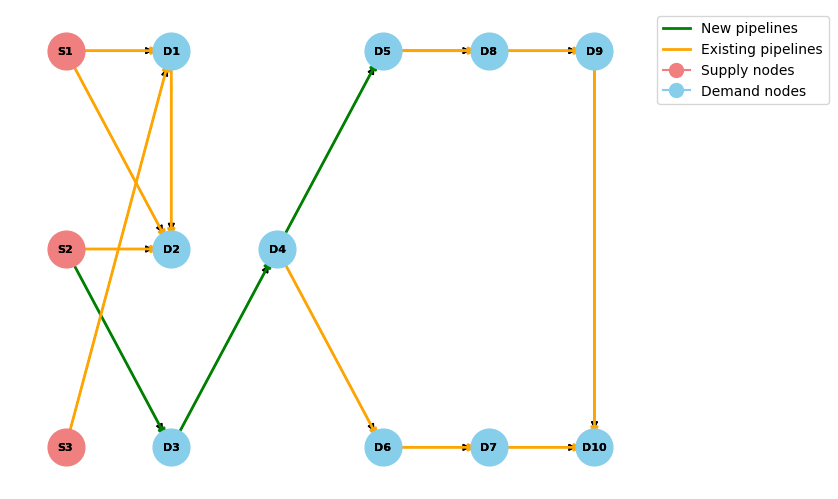

In [95]:
#plot methane grid
G.add_edges_from(edges_methane)

# Separate edges by type
new_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'new']
existing_edges = [(u, v) for u, v, d in G.edges(data=True) if d['type'] == 'existing']

# Plot the graph with node coordinates and different colors for edge types
pos = nodes
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=s_nodes, node_color='lightcoral', label='Supply nodes')
nx.draw(G, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=other_nodes, node_color='skyblue', label='Demand nodes')
nx.draw_networkx_edges(G, pos, edgelist=new_edges, edge_color='green', label='New edges', width=2)
nx.draw_networkx_edges(G, pos, edgelist=existing_edges, edge_color='orange', label='Existing edges', width=2)

# Create separate Line2D objects for each edge type for the legend
legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='New pipelines'),
    Line2D([0], [0], color='orange', lw=2, label='Existing pipelines'),
    Line2D([0], [0], marker='o', color='lightcoral', markerfacecolor='lightcoral', markersize=10, label='Supply nodes'),
    Line2D([0], [0], marker='o', color='skyblue', markerfacecolor='skyblue', markersize=10, label='Demand nodes'),
]

# Display the legend with adjusted position and include node and edge elements
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

#output_filepath = os.path.join(output_folder, 'network_methane_plot.png')
plt.savefig(images_folder_path + 'network_methane_plot.png', bbox_inches='tight')


# Display the plot
plt.show()

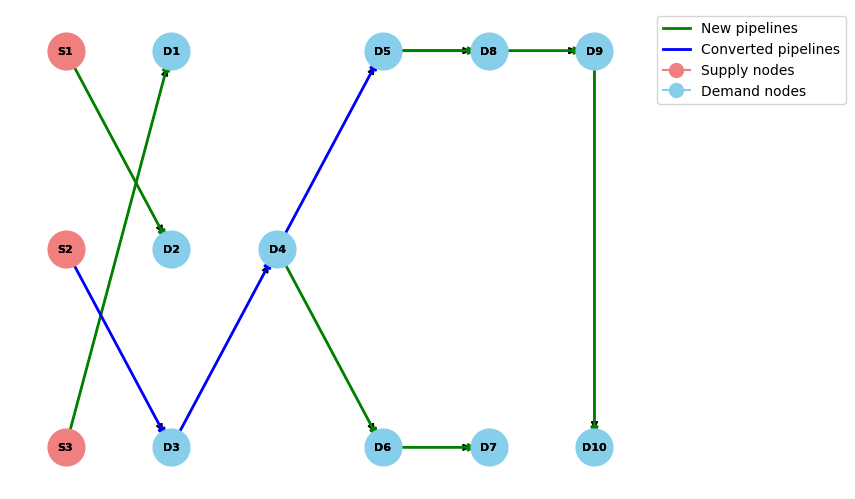

In [74]:
#plot hydrogen grid

G_hydrogen = nx.DiGraph()

G_hydrogen.add_edges_from(edges_hy)

# Separate edges by type
new_edges = [(u, v) for u, v, d in G_hydrogen.edges(data=True) if d['type'] == 'new']
converted_edges = [(u, v) for u, v, d in G_hydrogen.edges(data=True) if d['type'] == 'converted']

# Plot the graph with node coordinates and different colors for edge types
pos = nodes
nx.draw(G_hydrogen, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=s_nodes, node_color='lightcoral', label='Supply nodes')
nx.draw(G_hydrogen, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
        nodelist=other_nodes, node_color='skyblue', label='Demand nodes')
nx.draw_networkx_edges(G_hydrogen, pos, edgelist=new_edges, edge_color='green', label='New edges', width=2)
nx.draw_networkx_edges(G_hydrogen, pos, edgelist=converted_edges, edge_color='blue', label='Existing edges', width=2)

# Create separate Line2D objects for each edge type for the legend
legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='New pipelines'),
    Line2D([0], [0], color='blue', lw=2, label='Converted pipelines'),
    Line2D([0], [0], marker='o', color='lightcoral', markerfacecolor='lightcoral', markersize=10, label='Supply nodes'),
    Line2D([0], [0], marker='o', color='skyblue', markerfacecolor='skyblue', markersize=10, label='Demand nodes'),
]

# Display the legend with adjusted position and include node and edge elements
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.savefig(images_folder_path + 'network_hydrogen_plot.png', bbox_inches='tight')

# Display the plot
plt.show()

ModuleNotFoundError: No module named 'scipy'

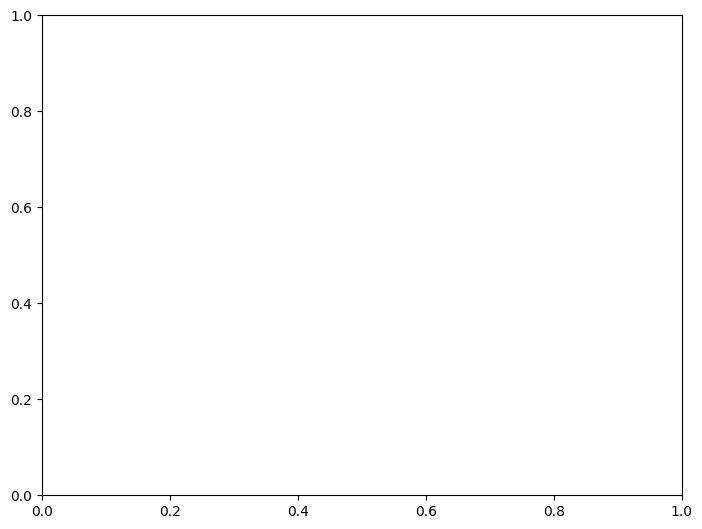

In [25]:
#plot real grid


# Transform the unique_nodes dataframe to dictionary format
unique_nodes_list = unique_nodes.set_index('node_name')['coordinates'].to_dict()

# Convert DataFrame to a list of dictionaries
records = edges_original_network_df.to_dict(orient='records')

# Create the desired list with headers included
edges_list_representation = [(record['source_name'], record['target_name'], {'type': record['type']}) for record in records]

G_real = nx.Graph()


G_real.add_nodes_from(unique_nodes_list)
original_nodes = [node for node in G_real.nodes if 'n' in node]

G_real.add_edges_from(edges_list_representation)

# Create a GeoDataFrame for plotting
#geometry = [Point(lon, lat) for lat, lon in unique_nodes_list.values()]
#gdf = gpd.GeoDataFrame(geometry=geometry, index=unique_nodes_list.keys())

# Separate edges by type
edges = [(u, v) for u, v, d in G_real.edges(data=True) if d['type'] == 'existing']

# Plot the graph with node coordinates and different colors for edge types
pos = unique_nodes_list
nx.draw(G_real, pos, with_labels=True, font_weight='bold', node_size=100, font_color='black', font_size=8,
        nodelist=original_nodes, node_color='lightcoral', label='Nodes')
#nx.draw(G_real, pos, with_labels=True, font_weight='bold', node_size=700, font_color='black', font_size=8,
#        nodelist=other_nodes, node_color='skyblue', label='Demand nodes')
nx.draw_networkx_edges(G_real, pos, edgelist=edges, edge_color='blue', label='Pipelines', width=2)

# Create separate Line2D objects for each edge type for the legend
legend_elements = [
    Line2D([0], [0], color='green', lw=2, label='New pipelines'),
    Line2D([0], [0], color='blue', lw=2, label='Converted pipelines'),
    Line2D([0], [0], marker='o', color='lightcoral', markerfacecolor='lightcoral', markersize=10, label='Supply nodes'),
    Line2D([0], [0], marker='o', color='skyblue', markerfacecolor='skyblue', markersize=10, label='Demand nodes'),
]

# Display the legend with adjusted position and include node and edge elements
plt.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.savefig(images_folder_path + 'network_original_plot.png', bbox_inches='tight')

# Display the plot
plt.show()

In [30]:
edges_original_network_df = edges_original_network_df.drop_duplicates()

edges_original_network_df

,source_name,target_name,type
0,node_0001,node_0002,existing
2,node_0002,node_0362,existing
3,node_0003,node_0004,existing
4,node_0003,node_0196,existing
5,node_0003,node_0381,existing
...,...,...,...
1015,node_0377,node_0656,existing
1016,node_0378,node_0611,existing
1017,node_0379,node_0657,existing
1018,node_0380,node_0658,existing


In [31]:
G = nx.Graph()

# Add nodes with coordinates
for idx, row in unique_nodes.iterrows():
    G.add_node(row['node_name'], pos=row['coordinates'])

# Add edges
for idx, row in edges_original_network_df.iterrows():
    G.add_edge(row['source_name'], row['target_name'], edge_type=row['type'])


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

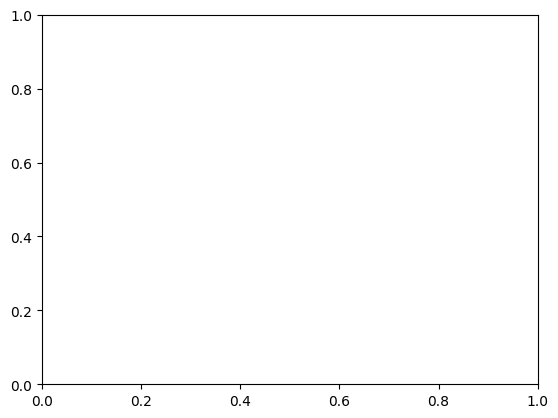

In [40]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Your node dataframe
node_data = pd.DataFrame({
    'node_name': ['node_0001', 'node_0002', 'node_0003'],
    'coordinates': [(757926.5454303586, 7207322.22114858),
                    (807807.6960599166, 7159118.912010687),
                    (681661.3396489053, 6764564.505472038)]
})

# Your edge dataframe
edge_data = pd.DataFrame({
    'source_name': ['node_0001', 'node_0001', 'node_0002'],
    'target_name': ['node_0002', 'node_0002', 'node_0003'],
    'type': ['existing', 'existing', 'existing']
})

# Create a graph and add nodes and edges
G = nx.Graph()

# Add nodes with coordinates
for idx, row in unique_nodes.iterrows():
    G.add_node(row['node_name'], pos=row['coordinates'])

# Add edges
for idx, row in edges_original_network_df.iterrows():
    G.add_edge(row['source_name'], row['target_name'], edge_type=row['type'])

# Plot the graph
pos = nx.get_node_attributes(G, 'pos')

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=200, node_color='skyblue', alpha=0.7)

# Draw edges with different colors for different edge types
edge_colors = ['g' if G[row[0]][row[1]]['edge_type'] == 'existing' else 'r' for row in G.edges()]
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2, alpha=0.7)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=8, font_color='black')

# Display the plot
plt.show()

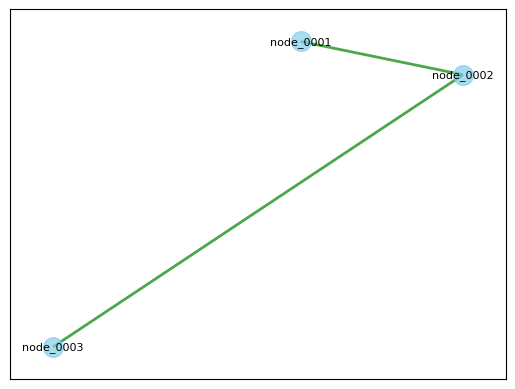

In [34]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Your node dataframe
node_data = pd.DataFrame({
    'node_name': ['node_0001', 'node_0002', 'node_0003'],
    'coordinates': [(757926.5454303586, 7207322.22114858),
                    (807807.6960599166, 7159118.912010687),
                    (681661.3396489053, 6764564.505472038)]
})

# Your edge dataframe
edge_data = pd.DataFrame({
    'source_name': ['node_0001', 'node_0001', 'node_0002'],
    'target_name': ['node_0002', 'node_0002', 'node_0003'],
    'type': ['existing', 'existing', 'existing']
})

# Create a graph and add nodes and edges
G = nx.Graph()

# Add nodes with coordinates
for idx, row in node_data.iterrows():
    G.add_node(row['node_name'], pos=row['coordinates'])

# Add edges
for idx, row in edge_data.iterrows():
    G.add_edge(row['source_name'], row['target_name'], edge_type=row['type'])

# Plot the graph
pos = nx.get_node_attributes(G, 'pos')

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=200, node_color='skyblue', alpha=0.7)

# Draw edges with different colors for different edge types
edge_colors = ['g' if G[row[0]][row[1]]['edge_type'] == 'existing' else 'r' for row in G.edges()]
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=2, alpha=0.7)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=8, font_color='black')

# Display the plot
plt.show()


C:\Users\jfg.eco\AppData\Local\Temp\ipykernel_19616\72128640.py:50: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


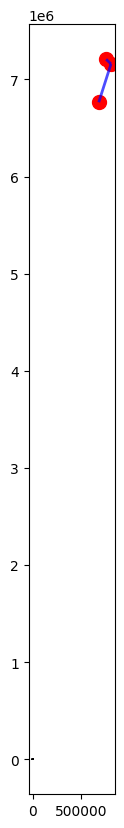

In [45]:
import pandas as pd
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt

# Your node dataframe
node_data = pd.DataFrame({
    'node_name': ['node_0001', 'node_0002', 'node_0003'],
    'coordinates': [(757926.5454303586, 7207322.22114858),
                    (807807.6960599166, 7159118.912010687),
                    (681661.3396489053, 6764564.505472038)]
})

# Your edge dataframe
edge_data = pd.DataFrame({
    'source_name': ['node_0001', 'node_0001', 'node_0002'],
    'target_name': ['node_0002', 'node_0002', 'node_0003'],
    'type': ['existing', 'existing', 'existing']
})

# Create a graph and add nodes and edges
G = nx.Graph()

# Add nodes with coordinates
for idx, row in node_data.iterrows():
    G.add_node(row['node_name'], pos=row['coordinates'])

# Add edges
for idx, row in edge_data.iterrows():
    G.add_edge(row['source_name'], row['target_name'], edge_type=row['type'])

# Create a GeoDataFrame for nodes
geometry_nodes = [Point(xy) for xy in node_data['coordinates']]
gdf_nodes = gpd.GeoDataFrame(node_data, geometry=geometry_nodes, crs="EPSG:3035")

# Create a GeoDataFrame for edges
edges = []
for edge in G.edges(data=True):
    source_pos = node_data[node_data['node_name'] == edge[0]]['coordinates'].values[0]
    target_pos = node_data[node_data['node_name'] == edge[1]]['coordinates'].values[0]
    edges.append(LineString([source_pos, target_pos]))

# Extract edge types
edge_types = [edge[2]['edge_type'] for edge in G.edges(data=True)]

gdf_edges = gpd.GeoDataFrame({'type': edge_types, 'geometry': edges}, crs="EPSG:3035")

# Plot the map
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
ax = world.plot(figsize=(10, 10), color='white', edgecolor='black')

# Plot nodes
gdf_nodes.plot(ax=ax, marker='o', color='red', markersize=100)

# Plot edges
gdf_edges[gdf_edges['type'] == 'existing'].plot(ax=ax, color='blue', linewidth=2, alpha=0.7)

plt.show()


C:\Users\jfg.eco\AppData\Local\Temp\ipykernel_19616\1459812260.py:46: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  germany_boundaries = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
C:\Users\jfg.eco\AppData\Local\Temp\ipykernel_19616\1459812260.py:58: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_nodes_clipped.plot(ax=ax, marker='o', color='red', markersize=100)
C:\Users\jfg.eco\AppData\Local\Temp\ipykernel_19616\1459812260.py:61: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  gdf_edges_clipped[gdf_edges_clipped['type'] == 'existing'].plot(ax=ax, color='blue', linewidth=2, alpha=0.7)


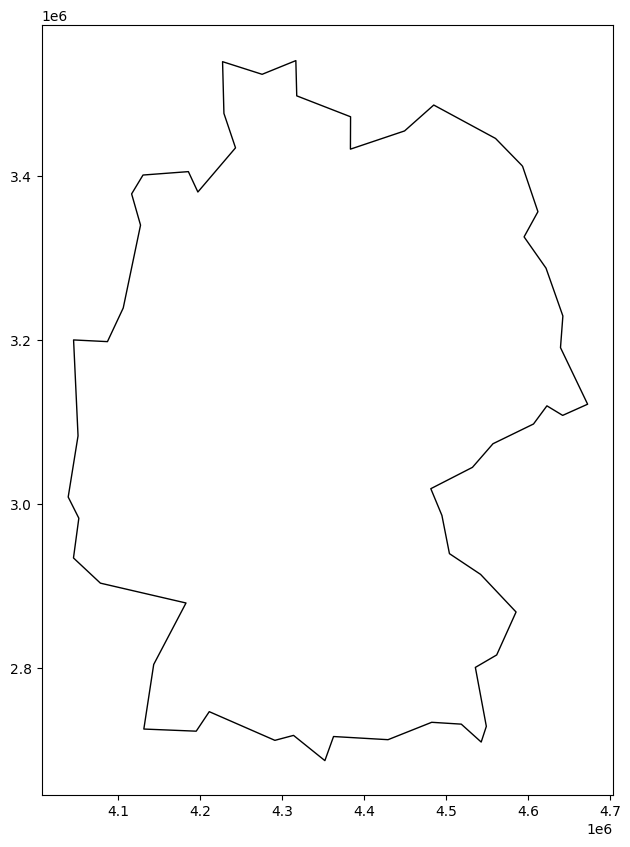

In [48]:
import pandas as pd
import networkx as nx
import geopandas as gpd
from shapely.geometry import Point, LineString
import matplotlib.pyplot as plt

# Your node dataframe
node_data = pd.DataFrame({
    'node_name': ['node_0001', 'node_0002', 'node_0003'],
    'coordinates': [(757926.5454303586, 7207322.22114858),
                    (807807.6960599166, 7159118.912010687),
                    (681661.3396489053, 6764564.505472038)]
})

# Your edge dataframe
edge_data = pd.DataFrame({
    'source_name': ['node_0001', 'node_0001', 'node_0002'],
    'target_name': ['node_0002', 'node_0002', 'node_0003'],
    'type': ['existing', 'existing', 'existing']
})

# Create a graph and add nodes and edges
G = nx.Graph()

# Add nodes with coordinates
for idx, row in node_data.iterrows():
    G.add_node(row['node_name'], pos=row['coordinates'])

# Create a GeoDataFrame for nodes
geometry_nodes = [Point(xy) for xy in node_data['coordinates']]
gdf_nodes = gpd.GeoDataFrame(node_data, geometry=geometry_nodes, crs="EPSG:3035")

# Create a GeoDataFrame for edges
edges = []
for edge in G.edges(data=True):
    source_pos = node_data[node_data['node_name'] == edge[0]]['coordinates'].values[0]
    target_pos = node_data[node_data['node_name'] == edge[1]]['coordinates'].values[0]
    edges.append(LineString([source_pos, target_pos]))

# Extract edge types
edge_types = [edge[2]['edge_type'] for edge in G.edges(data=True)]

gdf_edges = gpd.GeoDataFrame({'type': edge_types, 'geometry': edges}, crs="EPSG:3035")

# Load the GeoDataFrame for the boundaries of Germany and reproject to EPSG:3035
germany_boundaries = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
germany_boundaries = germany_boundaries.to_crs("EPSG:3035")
germany = germany_boundaries[germany_boundaries['name'] == 'Germany']

# Clip the GeoDataFrames to the extent of Germany using geopandas.clip
gdf_nodes_clipped = gpd.clip(gdf_nodes, germany.unary_union)
gdf_edges_clipped = gpd.clip(gdf_edges, germany.unary_union)

# Plot the map
ax = germany.plot(figsize=(10, 10), color='white', edgecolor='black')

# Plot nodes
gdf_nodes_clipped.plot(ax=ax, marker='o', color='red', markersize=100)

# Plot edges
gdf_edges_clipped[gdf_edges_clipped['type'] == 'existing'].plot(ax=ax, color='blue', linewidth=2, alpha=0.7)

plt.show()
